# XGBoost SHAP Analysis

Интерпретация XGBoost-модели из [xgb_model.ipynb](/Users/akmulein/cocrystal-prediction/notebooks/xgb_model.ipynb) с помощью SHAP

In [ ]:
from pathlib import Path
import sys
import pickle
from textwrap import fill

root = Path('..').resolve()
if str(root) not in sys.path:
    sys.path.append(str(root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split


### Загрузка данных и служебные функции

In [2]:
full_train_df = pd.read_pickle(root / 'data' / 'final' / 'triple_real_xtb.pkl')
holdout_df = pd.read_pickle(root / 'data' / 'final' / 'holdout_rebuilt_xtb.pkl')
sulf_df = pd.read_pickle(root / 'data' / 'final' / 'sulf_rebuilt_xtb.pkl')

train_df, test_df = train_test_split(
    full_train_df,
    test_size=0.2,
    random_state=42,
    stratify=full_train_df['cryst'],
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)


In [19]:
res_path = (root / 'models' / 'xgb_shap')

In [ ]:
with open(root / 'models' / 'xgb_train3d.pkl', 'rb') as f:
    clf = pickle.load(f)

feature_names = list(pd.read_pickle(root / 'data' / 'xtb' / 'xtb_feature_order_405.pkl'))

feature_names_df = pd.read_csv(
    root / 'resources' / 'xtb_features_names.csv',
    sep=';',
    encoding='utf-8-sig',
    usecols=['feature', 'name'],
)

feature_description_map = dict(zip(feature_names_df['feature'], feature_names_df['name']))
molecule_name_map = {
    'm1': 'Мол 1',
    'm2': 'Мол 2',
    'm3': 'Мол 3',
}


In [ ]:
def stack_features(df, x_col):
    return np.asarray(np.vstack(df[x_col].to_numpy()), dtype=float)


def feature_label(feature_name, width=42):
    molecule, short_name = feature_name.split('_', 1)
    description = feature_description_map[short_name]
    return fill(f"{molecule_name_map[molecule]}: {description}", width=width)


def compute_shap(df, x_col, name, sample_size=None, random_state=42):
    work_df = df
    if sample_size is not None and len(work_df) > sample_size:
        work_df = work_df.sample(sample_size, random_state=random_state)

    work_df = work_df.reset_index(drop=True)
    X = stack_features(work_df, x_col)
    X_df = pd.DataFrame(X, columns=[feature_label(name) for name in feature_names])

    shap_values = shap.TreeExplainer(clf).shap_values(X)
    if isinstance(shap_values, list):
        shap_values = shap_values[-1]

    return {
        'name': name,
        'X_df': X_df,
        'shap_values': np.asarray(shap_values, dtype=float),
    }


def plot_shap(values, max_display=20):
    plt.figure(figsize=(10, 10))
    shap.summary_plot(
        values['shap_values'],
        values['X_df'],
        max_display=max_display,
        show=False,
    )
    plt.title(values['name'], fontsize=16, pad=12)
    plt.tight_layout()
    plt.show()


def plot_shap_pair(left_values, right_values, max_display=20):
    fig, axes = plt.subplots(1, 2, figsize=(24, 10))

    plt.sca(axes[0])
    shap.summary_plot(
        left_values['shap_values'],
        left_values['X_df'],
        max_display=max_display,
        show=False,
        plot_size=None,
    )
    axes[0].set_title(left_values['name'], fontsize=16)

    plt.sca(axes[1])
    shap.summary_plot(
        right_values['shap_values'],
        right_values['X_df'],
        max_display=max_display,
        show=False,
        plot_size=None,
    )
    axes[1].set_title(right_values['name'], fontsize=16)

    plt.tight_layout()
    plt.show()


In [ ]:
train_values = compute_shap(
    df=train_df,
    x_col='xtb_concat_3d',
    name='Обучающая выборка',
    sample_size=5000,
)

test_values = compute_shap(
    df=test_df,
    x_col='xtb_concat_3d',
    name='Тестовая выборка',
)

plot_shap_pair(train_values, test_values, max_display=20)


In [ ]:
holdout_rebuilt_values = compute_shap(
    df=holdout_df,
    x_col='xtb_concat_rebuilt',
    name='Контрольная выборка (восстановленные геометрии)',
)

holdout_real_values = compute_shap(
    df=holdout_df,
    x_col='xtb_concat_3d',
    name='Контрольная выборка (экспериментальные геометрии)',
)

plot_shap_pair(holdout_rebuilt_values, holdout_real_values, max_display=20)


In [ ]:
experimental_values = compute_shap(
    df=sulf_df,
    x_col='xtb_concat_rebuilt',
    name='Экспериментальная выборка',
)

plot_shap(experimental_values, max_display=20)


На обучающей и тестовой выборках модель использует одну и ту же систему признаков. В обоих случаях наибольший вклад в предсказание вносят дескрипторы, характеризующие электронную структуру и пространственную форму компонентов, прежде всего радиус инерции, число свободных орбиталей, энергию на атом, полярность, статистики порядков связей, а также распределение энергий занятых и свободных орбиталей. Несколько более выраженный вклад чаще дают признаки третьей молекулы, однако решение модели не сводится к анализу одного компонента и формируется совокупностью характеристик всей системы. 

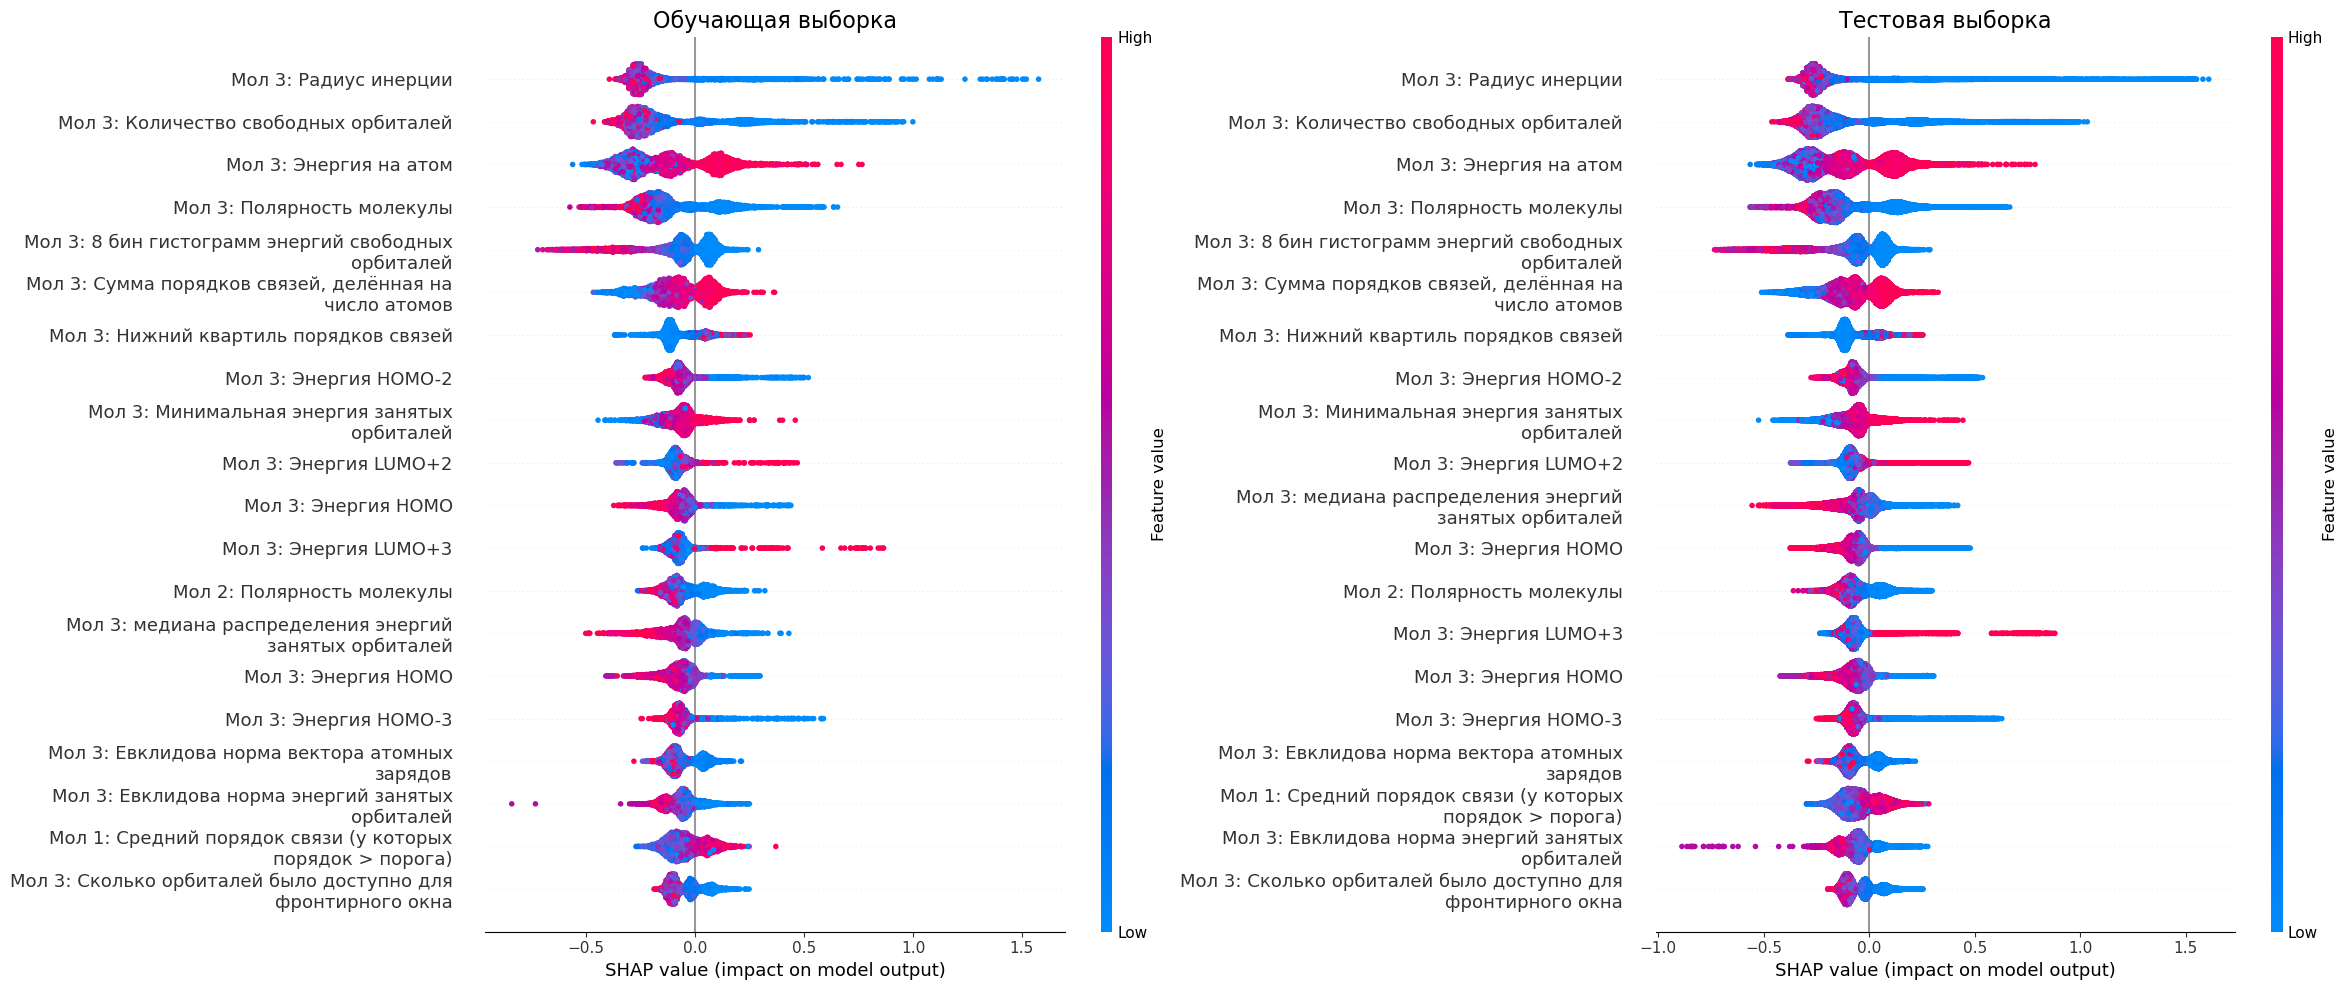

In [17]:
plot_shap_pair(train_values, test_values, 'train_test_shap.png', max_display=20)

На контрольной выборке, рассмотренной в двух вариантах геометрии, с экспериментальными и восстановленными координатами, структура вкладов остается практически неизменной, что указывает на сохранение основной логики модели при переходе от реальных кристаллографических геометрий к геометриям, восстановленным из двумерных представлений. 

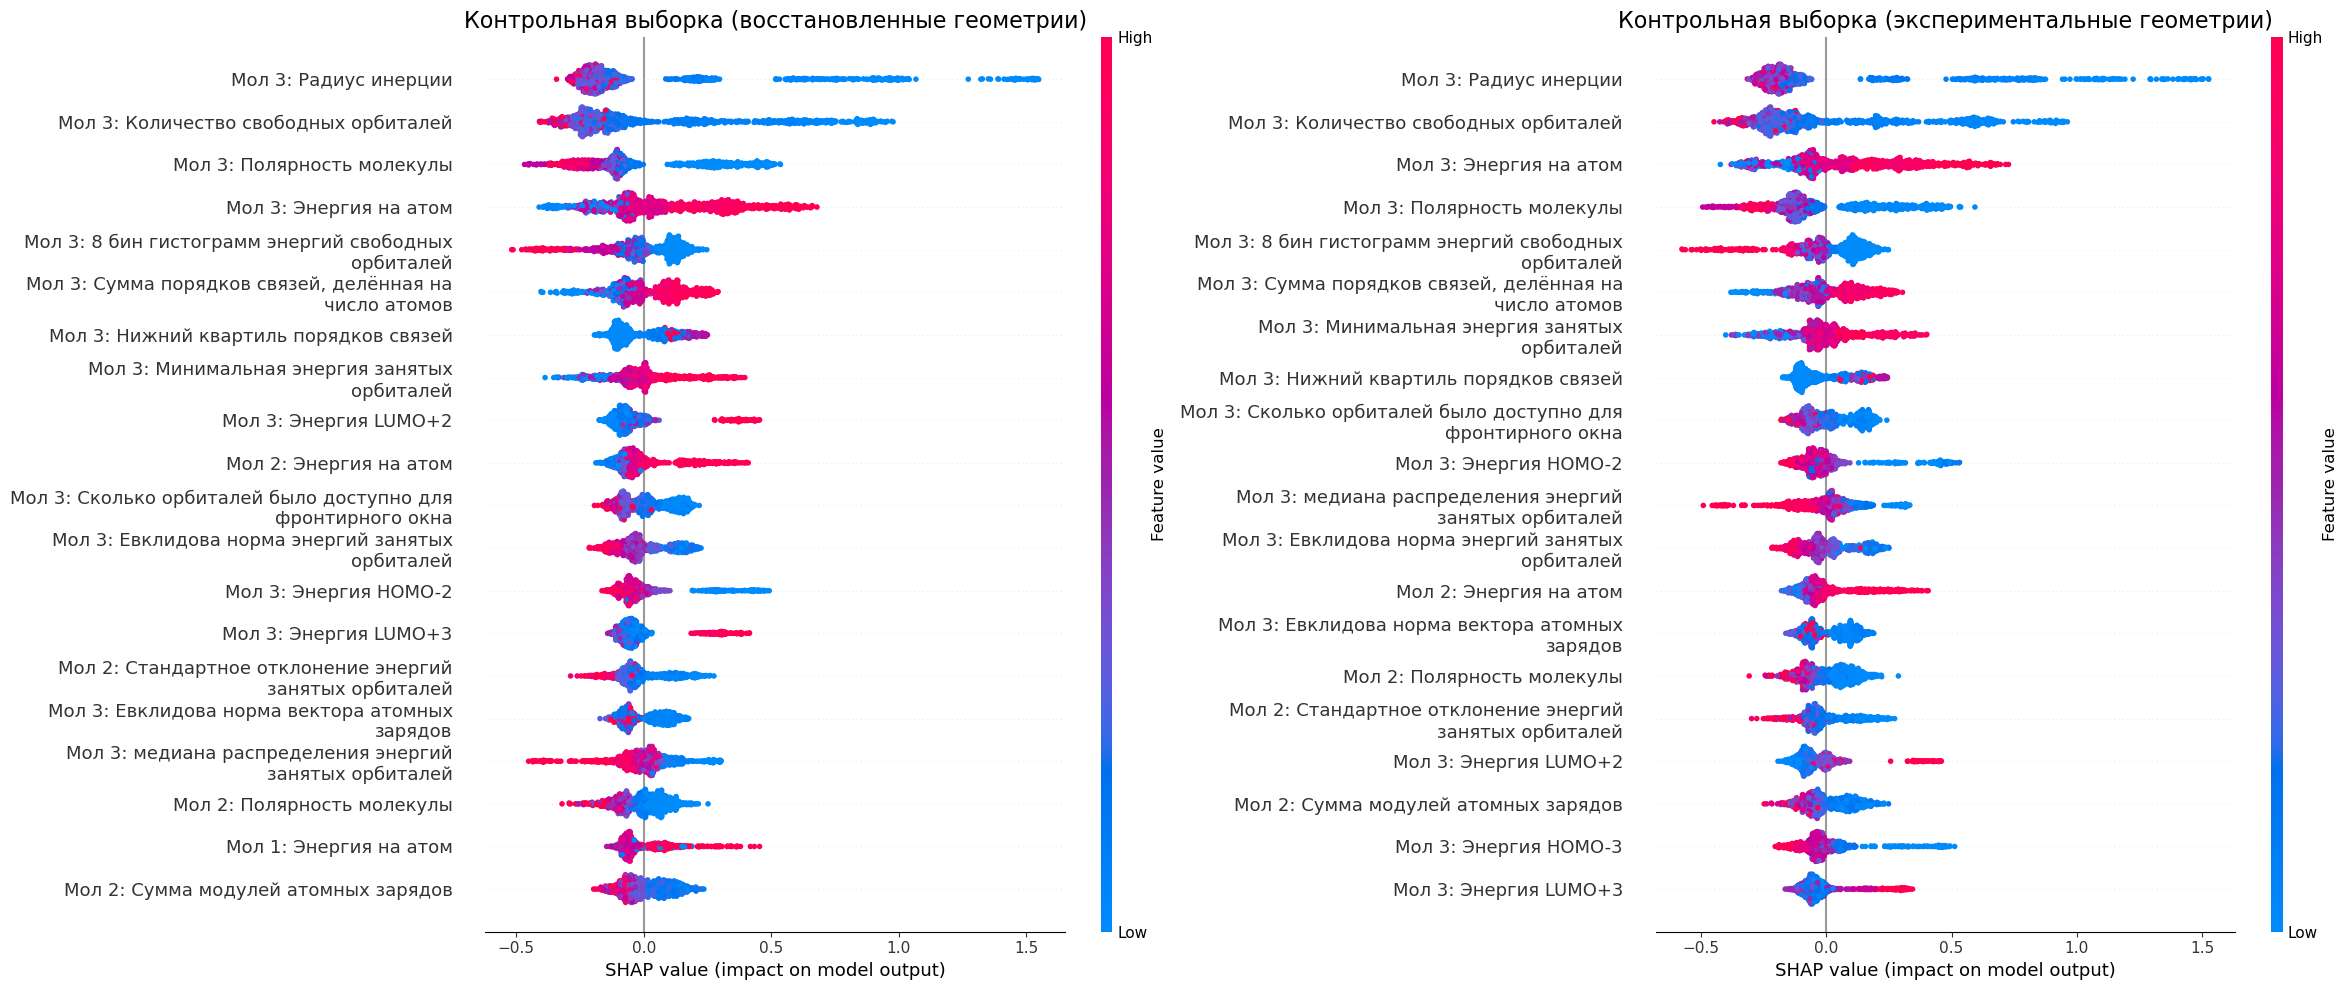

In [14]:
plot_shap_pair(holdout_rebuilt_values, holdout_real_values, 'holdout_shap.png', max_display=20)

На экспериментальном датасете вклады отдельных признаков становятся менее выраженными по модулю, а их важность распределяется более равномерно между всеми тремя молекулами (Рис.  8). Это показывает, что вне основного обучающего распределения бустинговая модель опирается на менее устойчивый сигнал, хотя и сохраняет физически осмысленную интерпретацию, основанную на электронно-структурных, геометрических и зарядовых свойствах компонентов системы.

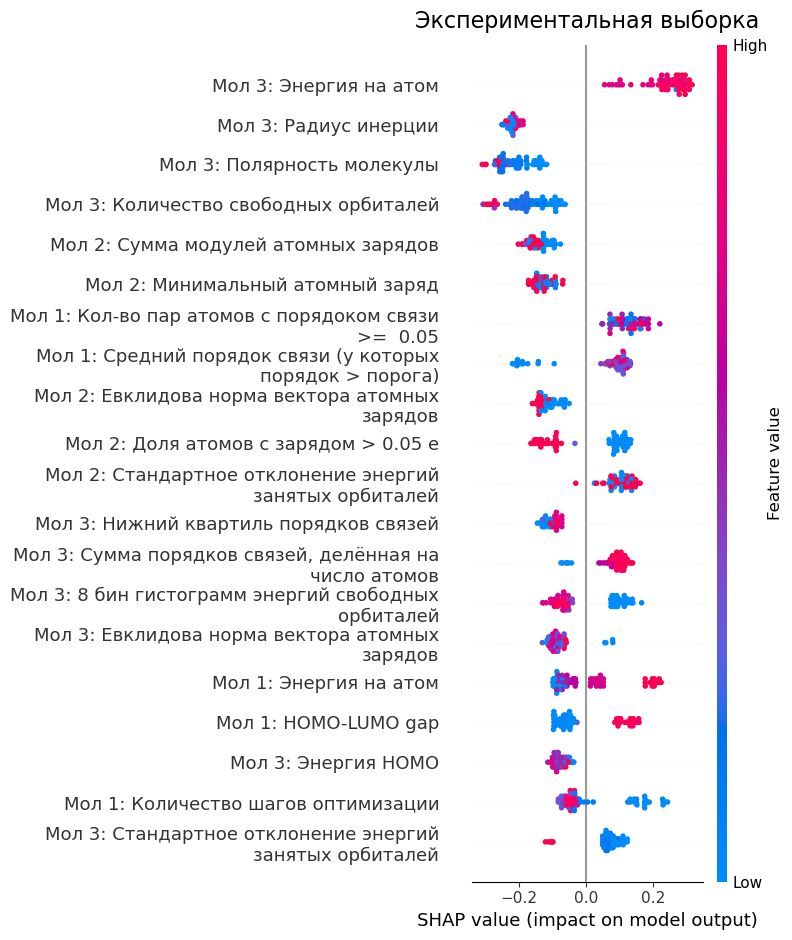

In [15]:
plot_shap(experimental_values, 'experimental_shap.png', max_display=20)

In [21]:
res_path = root / 'models' / 'xgb_shap'
res_path.mkdir(parents=True, exist_ok=True)

pd.to_pickle(train_values, res_path / 'train_shap_values.pkl')
pd.to_pickle(test_values, res_path / 'test_shap_values.pkl')

pd.to_pickle(holdout_rebuilt_values, res_path / 'holdout_rebuilt_shap_values.pkl')
pd.to_pickle(holdout_real_values, res_path / 'holdout_real_shap_values.pkl')

pd.to_pickle(experimental_values, res_path / 'experimental_shap_values.pkl')
